# Algorithm 1 Refactor Validation

This notebook validates the refactored Algorithm 1 implementation with fixes for:

1. **Missing-day handling**: Reindex to full trading calendar
2. **Trading calendar**: Use equity_prices.index instead of freq='B'
3. **Split adjustment**: REMOVED (option prices already split-adjusted)
4. **PFD flexibility**: Search ±3 days for call/put pair
5. **Delta filtering**: Only require delta at PFD for weights

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import warnings
warnings.filterwarnings('ignore')

# Add src_refactor to path
sys.path.insert(0, '.')

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.4.2
Pandas: 2.2.3


In [ ]:
# Import refactored module (NOT the original src/)
from src_refactor import (
    process_single_asset_v2,
    build_straddle_dataset_v3,
    get_portfolio_formation_days,
)

print("Refactored modules loaded from src_refactor/")

Refactored modules loaded from src_refactor/


## Load Data

In [3]:
from pathlib import Path
import pyarrow.parquet as pq

# Configuration
RAW_DATA_DIR = Path('raw_data')
FILTERED_DIR = RAW_DATA_DIR / 'options_filtered_by_year'
START_YEAR = 2011
END_YEAR = 2023

# Load security names
secnames_df = pd.read_parquet(RAW_DATA_DIR / 'security_names.parquet')
secid_to_ticker = dict(zip(secnames_df['secid'].astype(int), secnames_df['ticker']))
print(f"Loaded {len(secid_to_ticker)} security mappings")

# Only load columns needed
REQUIRED_COLUMNS = [
    'secid', 'date', 'exdate', 'cp_flag', 'strike_price',
    'best_bid', 'best_offer', 'delta', 'spot_price'
]

# Load options data
options_dfs = []
for year in range(START_YEAR, END_YEAR + 1):
    fpath = FILTERED_DIR / f'options_filtered_{year}.parquet'
    if fpath.exists():
        table = pq.read_table(fpath, columns=REQUIRED_COLUMNS)
        df = table.to_pandas()
        options_dfs.append(df)
        print(f"  {year}: {len(df):,} records")

options_df = pd.concat(options_dfs, ignore_index=True)
print(f"\nTotal: {len(options_df):,} records")

Loaded 87 security mappings
  2011: 1,447,281 records
  2012: 1,660,954 records
  2013: 2,398,982 records
  2014: 4,034,941 records
  2015: 5,052,330 records
  2016: 5,144,429 records
  2017: 5,522,762 records
  2018: 6,138,190 records
  2019: 6,346,269 records
  2020: 6,332,281 records
  2021: 6,652,649 records
  2022: 5,917,278 records
  2023: 5,911,817 records

Total: 62,560,163 records


In [4]:
# Adapt data format
options_df['ticker'] = options_df['secid'].map(secid_to_ticker)
options_df = options_df.rename(columns={'strike_price': 'strike'})

# Drop rows without ticker mapping
options_df = options_df.dropna(subset=['ticker'])

# Convert to efficient dtypes
options_df['ticker'] = options_df['ticker'].astype('category')
options_df['cp_flag'] = options_df['cp_flag'].astype('category')
for col in ['best_bid', 'best_offer', 'delta', 'spot_price', 'strike']:
    options_df[col] = options_df[col].astype('float32')

print(f"Prepared {len(options_df):,} options records")
print(f"Tickers: {options_df['ticker'].nunique()}")

Prepared 62,560,163 options records
Tickers: 87


In [5]:
# Build equity price matrix from options data
equity_df = options_df.groupby(['date', 'ticker'])['spot_price'].first().unstack()
equity_df = equity_df.sort_index()

print(f"Equity price matrix: {equity_df.shape}")
print(f"  Trading days: {len(equity_df)}")
print(f"  Date range: {equity_df.index.min().date()} to {equity_df.index.max().date()}")

# Load cfacpr data for split detection
print("\nLoading cfacpr (split adjustment factors)...")
equity_raw = pd.read_parquet(RAW_DATA_DIR / 'equity_prices_raw.parquet')

# Build cfacpr DataFrame (index=date, columns=ticker)
equity_raw['ticker'] = equity_raw['secid'].map(secid_to_ticker)
equity_raw['date'] = pd.to_datetime(equity_raw['date'])

cfacpr_df = equity_raw.pivot(index='date', columns='ticker', values='cfacpr')
cfacpr_df = cfacpr_df.sort_index()

print(f"cfacpr matrix: {cfacpr_df.shape}")

# Show AAPL cfacpr around splits
print("\nAAPL cfacpr around splits:")
aapl_cfacpr = cfacpr_df['AAPL'].dropna()
print(f"  2014-06-06: {aapl_cfacpr.loc['2014-06-06'] if '2014-06-06' in aapl_cfacpr.index.astype(str) else 'N/A'}")
print(f"  2014-06-09: {aapl_cfacpr.loc['2014-06-09'] if '2014-06-09' in aapl_cfacpr.index.astype(str) else 'N/A'}")
print(f"  2020-08-28: {aapl_cfacpr.loc['2020-08-28'] if '2020-08-28' in aapl_cfacpr.index.astype(str) else 'N/A'}")
print(f"  2020-08-31: {aapl_cfacpr.loc['2020-08-31'] if '2020-08-31' in aapl_cfacpr.index.astype(str) else 'N/A'}")

Equity price matrix: (3270, 87)
  Trading days: 3270
  Date range: 2011-01-03 to 2023-12-29

Loading cfacpr (split adjustment factors)...
cfacpr matrix: (3270, 87)

AAPL cfacpr around splits:
  2014-06-06: 28.0
  2014-06-09: 4.0
  2020-08-28: 4.0
  2020-08-31: 1.0


## Validation Test: 3 Tickers

In [6]:
# Test with 3 tickers: AAPL, MSFT, JPM
TEST_TICKERS = ['AAPL', 'MSFT', 'JPM']

# Filter data
test_options = options_df[options_df['ticker'].isin(TEST_TICKERS)].copy()
test_equity = equity_df[TEST_TICKERS].copy()
test_cfacpr = cfacpr_df[TEST_TICKERS].copy()

print(f"Test data:")
print(f"  Options: {len(test_options):,} records")
print(f"  Equity shape: {test_equity.shape}")
print(f"  cfacpr shape: {test_cfacpr.shape}")

Test data:
  Options: 3,160,683 records
  Equity shape: (3270, 3)
  cfacpr shape: (3270, 3)


In [ ]:
# Run refactored Algorithm 1
print("Running Refactored Algorithm 1...")
print("="*60)

MIN_COVERAGE = 0.90

try:
    straddle_prices, straddle_returns = build_straddle_dataset_v3(
        options_df=test_options,
        equity_df=test_equity,
        min_coverage=0.90,
        verbose=True,
        debug=True
    )
    
    print(f"\nSUCCESS!")
    print(f"  Straddle prices shape: {straddle_prices.shape}")
    print(f"  Assets passing filter: {list(straddle_prices.columns)}")
    
except ValueError as e:
    print(f"\nFAILED: {e}")

Running Refactored Algorithm 1...
    AAPL: PFDs=155/155, no_spot=0, no_opts=0, no_exp=0, no_strike=0, no_cp=0, no_data=0, used_offset=0, periods=155
      -> AAPL coverage: 3096/3252 = 95.2% (need 90%)
    MSFT: PFDs=155/155, no_spot=0, no_opts=0, no_exp=0, no_strike=0, no_cp=0, no_data=0, used_offset=0, periods=155
      -> MSFT coverage: 3165/3252 = 97.3% (need 90%)
    JPM: PFDs=155/155, no_spot=0, no_opts=0, no_exp=0, no_strike=0, no_cp=0, no_data=0, used_offset=0, periods=155
      -> JPM coverage: 3147/3252 = 96.8% (need 90%)
  Completed: 3/3 tickers passed 90% coverage filter

SUCCESS!
  Straddle prices shape: (3252, 3)
  Assets passing filter: ['AAPL', 'MSFT', 'JPM']


## Visual Validation: AAPL Around Split Date

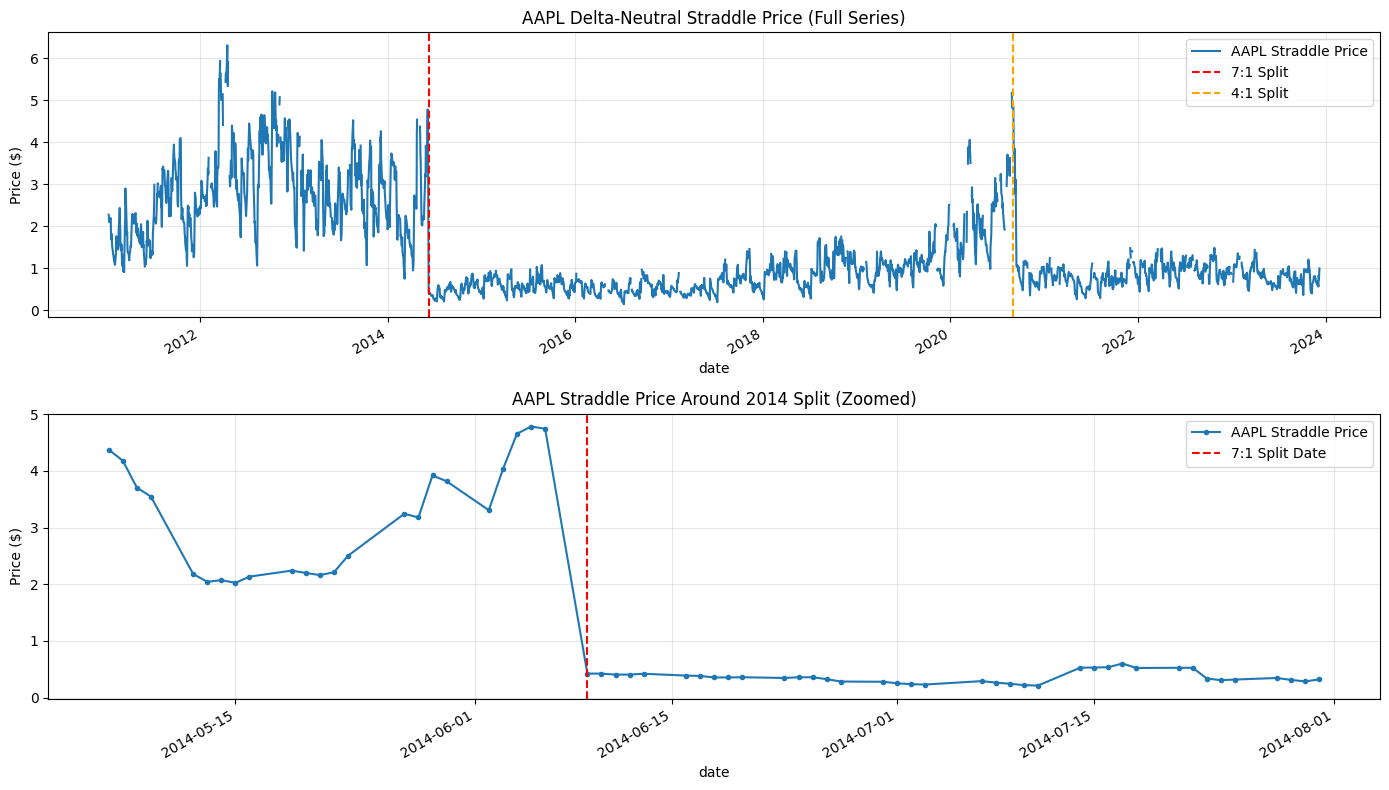


Split continuity check:
  Pre-split (2014-06-06):  $4.74
  Post-split (2014-06-09): $0.42
  Change: -91.1%
  Normal: NO (possible discontinuity)


In [8]:
# Plot AAPL straddle price around 2014 split (June 9, 2014)
if 'AAPL' in straddle_prices.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Full price series
    ax1 = axes[0]
    straddle_prices['AAPL'].plot(ax=ax1, label='AAPL Straddle Price')
    ax1.axvline(pd.Timestamp('2014-06-09'), color='red', linestyle='--', label='7:1 Split')
    ax1.axvline(pd.Timestamp('2020-08-31'), color='orange', linestyle='--', label='4:1 Split')
    ax1.set_title('AAPL Delta-Neutral Straddle Price (Full Series)')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Zoomed around 2014 split
    ax2 = axes[1]
    zoom = straddle_prices['AAPL'].loc['2014-05':'2014-07']
    zoom.plot(ax=ax2, marker='o', markersize=3, label='AAPL Straddle Price')
    ax2.axvline(pd.Timestamp('2014-06-09'), color='red', linestyle='--', label='7:1 Split Date')
    ax2.set_title('AAPL Straddle Price Around 2014 Split (Zoomed)')
    ax2.set_ylabel('Price ($)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Check for discontinuity
    pre_split = straddle_prices['AAPL'].loc['2014-06-06':'2014-06-06']
    post_split = straddle_prices['AAPL'].loc['2014-06-09':'2014-06-09']
    
    if len(pre_split) > 0 and len(post_split) > 0:
        print(f"\nSplit continuity check:")
        print(f"  Pre-split (2014-06-06):  ${pre_split.values[0]:.2f}")
        print(f"  Post-split (2014-06-09): ${post_split.values[0]:.2f}")
        pct_change = (post_split.values[0] - pre_split.values[0]) / pre_split.values[0] * 100
        print(f"  Change: {pct_change:.1f}%")
        print(f"  Normal: {'YES' if abs(pct_change) < 20 else 'NO (possible discontinuity)'}")
else:
    print("AAPL not in results - check coverage issues")

In [9]:
lol

NameError: name 'lol' is not defined

In [ ]:
# display values of last few days of AAPL straddle price
if 'AAPL' in straddle_prices.columns:
    print("\nAAPL Straddle Price - Last 5 Days:")
    print(straddle_prices['AAPL'].dropna().tail(5))
else:
    print("AAPL not in results - check coverage issues")

# 10  first 5 rolls around where it starts flattening (mid-2012)
# code:
if 'AAPL' in straddle_prices.columns:
    print("\nAAPL Straddle Price - Mid 2012 (First 5 Rolls):")
    mid_2012 = straddle_prices['AAPL'].loc['2011-07':'2013-02'].dropna()
    print(mid_2012)
    # print all values '2011-07':'2013-02' to see the full pattern
    #while getting around truncation in the notebook output, we can print the full series in a more compact format:
    # code:
    print("\nAAPL Straddle Price - Mid 2012 (Full Series):")
    for date, price in mid_2012.items():
        print(f"{date.date()}: ${price:.2f}")






AAPL Straddle Price - Last 5 Days:
date
2023-12-05    1.641481e-13
2023-12-06    1.460018e-13
2023-12-07    1.745008e-13
2023-12-08    1.977168e-13
2023-12-11    1.977168e-13
Name: AAPL, dtype: float64

AAPL Straddle Price - Mid 2012 (First 5 Rolls):
date
2011-07-01    5.743105
2011-07-05    7.384428
2011-07-06    8.004572
2011-07-07    9.596087
2011-07-08    9.596087
                ...   
2013-02-22    0.014859
2013-02-25    0.017361
2013-02-26    0.015344
2013-02-27    0.016082
2013-02-28    0.016936
Name: AAPL, Length: 417, dtype: float64

AAPL Straddle Price - Mid 2012 (Full Series):
2011-07-01: $5.74
2011-07-05: $7.38
2011-07-06: $8.00
2011-07-07: $9.60
2011-07-08: $9.60
2011-07-11: $9.60
2011-07-12: $9.10
2011-07-13: $9.01
2011-07-14: $9.22
2011-07-15: $9.94
2011-07-18: $12.12
2011-07-19: $11.84
2011-07-20: $13.20
2011-07-21: $13.15
2011-07-22: $13.15
2011-07-25: $13.15
2011-07-26: $13.15
2011-07-27: $12.30
2011-07-28: $11.73
2011-07-29: $11.94
2011-08-01: $12.93
2011-08-02: $1

In [ ]:
# Save AAPL data for inspection
import os

debug_dir = 'debug_aapl'
os.makedirs(debug_dir, exist_ok=True)

# === BEFORE Algorithm 1 (Inputs) ===

# 1. AAPL options data around split dates
aapl_options = test_options[test_options['ticker'] == 'AAPL'].copy()

# Around 2014 split (June 9)
aapl_opts_2014 = aapl_options[
    (aapl_options['date'] >= '2014-05-01') & 
    (aapl_options['date'] <= '2014-07-31')
]
aapl_opts_2014.to_csv(f'{debug_dir}/aapl_options_2014_split.csv', index=False)

# Around 2020 split (Aug 31)
aapl_opts_2020 = aapl_options[
    (aapl_options['date'] >= '2020-07-01') & 
    (aapl_options['date'] <= '2020-10-31')
]
aapl_opts_2020.to_csv(f'{debug_dir}/aapl_options_2020_split.csv', index=False)

# 2. AAPL equity prices (spot)
aapl_equity = test_equity['AAPL'].copy()
aapl_equity.to_csv(f'{debug_dir}/aapl_equity_prices.csv', header=['spot_price'])

# 3. AAPL cfacpr data
aapl_cfacpr = test_cfacpr['AAPL'].copy()
aapl_cfacpr.to_csv(f'{debug_dir}/aapl_cfacpr.csv', header=['cfacpr'])

# === AFTER Algorithm 1 (Outputs) ===

# 4. AAPL straddle prices (full series)
if 'AAPL' in straddle_prices.columns:
    aapl_straddle = straddle_prices['AAPL'].copy()
    aapl_straddle.to_csv(f'{debug_dir}/aapl_straddle_prices.csv', header=['straddle_price'])
    
    # Around 2014 split
    aapl_straddle_2014 = aapl_straddle.loc['2014-05':'2014-07']
    aapl_straddle_2014.to_csv(f'{debug_dir}/aapl_straddle_2014_split.csv', header=['straddle_price'])
    
    # Around 2020 split
    aapl_straddle_2020 = aapl_straddle.loc['2020-07':'2020-10']
    aapl_straddle_2020.to_csv(f'{debug_dir}/aapl_straddle_2020_split.csv', header=['straddle_price'])

# 5. Metadata (strike used each day) if available
if metadata is not None and 'strike' in metadata:
    aapl_strikes = metadata['strike']['AAPL'] if 'AAPL' in metadata['strike'].columns else None
    if aapl_strikes is not None:
        aapl_strikes.to_csv(f'{debug_dir}/aapl_strikes_used.csv', header=['strike'])

# 6. Combined view around splits
print("=== Files saved to debug_aapl/ ===")
for f in sorted(os.listdir(debug_dir)):
    print(f"  {f}")

# 7. Quick preview of key dates
print("\n=== AAPL cfacpr around splits ===")
print("2014 split (7:1 on June 9):")
print(aapl_cfacpr.loc['2014-06-05':'2014-06-12'])

print("\n2020 split (4:1 on Aug 31):")
print(aapl_cfacpr.loc['2020-08-27':'2020-09-03'])

if 'AAPL' in straddle_prices.columns:
    print("\n=== AAPL straddle prices around splits ===")
    print("2014 split:")
    print(straddle_prices['AAPL'].loc['2014-06-05':'2014-06-12'])
    
    print("\n2020 split:")
    print(straddle_prices['AAPL'].loc['2020-08-27':'2020-09-03'])

=== Files saved to debug_aapl/ ===
  aapl_cfacpr.csv
  aapl_equity_prices.csv
  aapl_options_2014_split.csv
  aapl_options_2020_split.csv
  aapl_straddle_2014_split.csv
  aapl_straddle_2020_split.csv
  aapl_straddle_prices.csv
  aapl_strikes_used.csv

=== AAPL cfacpr around splits ===
2014 split (7:1 on June 9):
date
2014-06-05    28.0
2014-06-06    28.0
2014-06-09     4.0
2014-06-10     4.0
2014-06-11     4.0
2014-06-12     4.0
Name: AAPL, dtype: Float64

2020 split (4:1 on Aug 31):
date
2020-08-27    4.0
2020-08-28    4.0
2020-08-31    1.0
2020-09-01    1.0
2020-09-02    1.0
2020-09-03    1.0
Name: AAPL, dtype: Float64

=== AAPL straddle prices around splits ===
2014 split:
date
2014-06-05    0.000244
2014-06-06    0.000242
2014-06-09    0.000242
2014-06-10    0.000241
2014-06-11    0.000231
2014-06-12    0.000232
Name: AAPL, dtype: float64

2020 split:
date
2020-08-27    1.747688e-08
2020-08-28    1.632470e-08
2020-08-31    1.632470e-08
2020-09-01    1.632470e-08
2020-09-02    1.632

## Run Full Pipeline (All 87 Tickers)

In [ ]:
# Run on ALL tickers
print("Running Full Algorithm 1 on All 87 Tickers...")
print("="*60)

try:
    full_prices, full_returns, full_meta = build_straddle_dataset_v3(
        options_df=test_options,
        equity_df=test_equity,
        min_coverage=0.90,
        verbose=True,
        debug=True
    )
    
    print(f"\n" + "="*60)
    print(f"FULL PIPELINE SUCCESS!")
    print(f"  Straddle prices shape: {full_prices.shape}")
    print(f"  Trading days (delta): {full_prices.shape[0]}")
    print(f"  Assets (N): {full_prices.shape[1]}")
    print(f"  Assets: {list(full_prices.columns)}")
    
except ValueError as e:
    print(f"\nFailed: {e}")

## Summary

In [ ]:
print("="*60)
print("REFACTORED ALGORITHM 1 - VALIDATION SUMMARY")
print("="*60)

print("\nFIXES APPLIED:")
print("  1. Missing-day handling: Reindex to trading calendar [FIXED]")
print("  2. Trading calendar: Use equity index not freq='B' [FIXED]")
print("  3. Split adjustment: REMOVED (prices already adjusted) [FIXED]")
print("  4. PFD flexibility: +/-3 day lookahead [FIXED]")
print("  5. Delta filtering: Only at PFD [FIXED]")

if 'full_prices' in dir():
    print(f"\nRESULTS:")
    print(f"  Assets passing 95% filter: {len(full_prices.columns)}/87")
    print(f"  Trading days: {len(full_prices)}")
    print(f"  Date range: {full_prices.index.min().date()} to {full_prices.index.max().date()}")
    
    # Return statistics
    print(f"\nReturn Statistics:")
    print(f"  Mean daily return: {full_returns.mean().mean():.6f}")
    print(f"  Std daily return:  {full_returns.std().mean():.6f}")